# Africa LNG Exports to the USA — Exploratory Analysis

**Domain:** Oil & Gas · **Focus:** Africa → USA and global LNG markets · **Period:** 2019–2023

This notebook explores the SQLite warehouse `data/lng_pipeline.db` produced by the pipeline
(`ingest → transform → load`). It answers:

1. Which African countries dominate LNG exports, and how did 2019 compare with 2023?
2. How have export values evolved through the COVID-19 shock and the 2022–23 European gas crisis?
3. How much African LNG goes to the **USA**, and who ships it?
4. How dependent are African economies on gas rents, and does that translate into higher incomes?

**Data notes.** The bundled UN Comtrade snapshot covers **2019, 2020 and 2023** for eight of the ten countries
(Algeria and Equatorial Guinea return no HS 271111 records from the public preview endpoint). Re-running
ingestion queries every reporter-year and also picks up 2021–2022.
World Bank rents series end in **2021**, so the processed table carries the latest value forward for 2023.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")

# Works whether the notebook is run from notebooks/ or the project root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "lng_pipeline.db"
assert DB_PATH.exists(), f"Run the pipeline first: {DB_PATH} not found"
conn = sqlite3.connect(DB_PATH)
print("Connected to", DB_PATH.name)

Connected to lng_pipeline.db


## 1. Data loading and overview

In [2]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
counts = {t: pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0] for t in tables["name"]}
pd.Series(counts, name="rows").to_frame()

,rows
lng_exports_processed,21
lng_trade_raw,275
wb_indicators,700
wb_indicators_wide,140


In [3]:
trade = pd.read_sql("SELECT * FROM lng_trade_raw", conn)
exports = pd.read_sql("SELECT * FROM lng_exports_processed", conn)
wb = pd.read_sql("SELECT * FROM wb_indicators_wide", conn)

print("Trade rows by flow (X=export, M=import, RX=re-export):")
print(trade["flow"].value_counts().to_string())
print("\nYears in Comtrade extract:", sorted(trade["year"].unique()))
print("Reporters:", ", ".join(sorted(trade["reporter"].unique())))
print("World Bank years:", wb["year"].min(), "-", wb["year"].max())
exports[["country", "year", "export_value_billion_usd", "usa_export_value_million_usd",
         "num_destinations", "top_destination", "gas_dependency_score"]].round(2)

Trade rows by flow (X=export, M=import, RX=re-export):
flow
X     231
M      37
RX      7

Years in Comtrade extract: [2019, 2020, 2023]
Reporters: Angola, Cameroon, Egypt, Gabon, Libya, Mozambique, Nigeria, Tanzania
World Bank years: 2012 - 2025


,country,year,export_value_billion_usd,usa_export_value_million_usd,num_destinations,top_destination,gas_dependency_score
0,Angola,2019,1.29,0.00,14,India,14.28
1,Angola,2020,0.90,0.00,14,India,15.23
2,Angola,2023,2.59,44.13,10,India,20.12
3,Cameroon,2019,0.45,0.00,8,China,27.10
4,Cameroon,2020,0.00,0.00,1,Congo,11.73
5,Cameroon,2023,0.70,0.00,5,France,30.74
6,Egypt,2019,1.24,0.00,20,Jordan,53.54
7,Egypt,2020,0.44,0.00,11,Pakistan,45.76
8,Egypt,2023,2.57,0.00,18,Turkey,57.32
9,Gabon,2019,0.00,0.00,1,USA,12.04


In [4]:
exports[["export_value_billion_usd", "usa_export_value_million_usd", "usa_share_pct",
         "num_destinations", "gas_rents_pct_gdp", "electricity_from_gas_pct",
         "gdp_per_capita_usd", "gas_dependency_score"]].describe().round(2)

,export_value_billion_usd,usa_export_value_million_usd,usa_share_pct,num_destinations,gas_rents_pct_gdp,electricity_from_gas_pct,gdp_per_capita_usd,gas_dependency_score
count,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
mean,1.35,14.80,9.83,10.00,1.09,45.95,2868.87,33.54
std,1.74,48.15,29.99,8.83,0.92,28.55,2535.09,18.24
min,0.00,0.00,0.00,1.00,0.13,8.82,462.43,11.73
25%,0.00,0.00,0.00,2.00,0.36,19.48,1224.00,17.70
50%,0.70,0.00,0.00,8.00,0.86,36.51,2138.76,27.10
75%,1.66,0.00,0.42,14.00,1.67,75.82,3189.81,48.31
max,5.97,218.79,100.00,27.00,3.57,86.55,9963.19,72.64


## 2. Top African LNG exporters — 2019 vs 2023

Totals use the Comtrade *World* aggregate per exporter-year, so bilateral rows are not double counted.

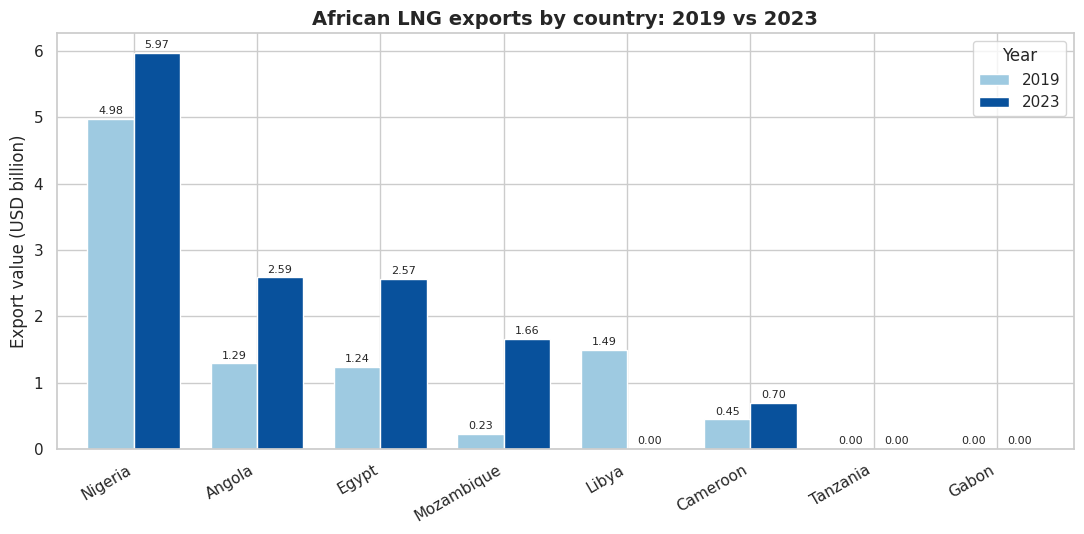

year,2019,2023
country,,
Nigeria,4.980,5.966
Angola,1.290,2.587
Egypt,1.236,2.566
Mozambique,0.231,1.658
Libya,1.490,0.000
Cameroon,0.447,0.700
Tanzania,0.004,0.001
Gabon,0.000,0.000


In [5]:
cmp = (exports[exports["year"].isin([2019, 2023])]
       .pivot_table(index="country", columns="year", values="export_value_billion_usd", aggfunc="sum")
       .fillna(0))
cmp = cmp.loc[cmp.max(axis=1).sort_values(ascending=False).index]

ax = cmp.plot(kind="bar", figsize=(11, 5.5), color=["#9ecae1", "#08519c"], width=0.75)
ax.set_title("African LNG exports by country: 2019 vs 2023", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Export value (USD billion)")
ax.legend(title="Year")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
cmp.round(3)

**Finding.** Nigeria is Africa's largest LNG exporter in every year (≈USD 5.0 bn in 2019 → ≈USD 6.0 bn in 2023).
Egypt and Angola roughly doubled their export values between 2019 and 2023, and Mozambique jumped from
≈USD 0.23 bn to ≈USD 1.66 bn after the Coral Sul FLNG project started production in late 2022.
Libya reported only for 2019 in this extract.

## 3. LNG export trends over time

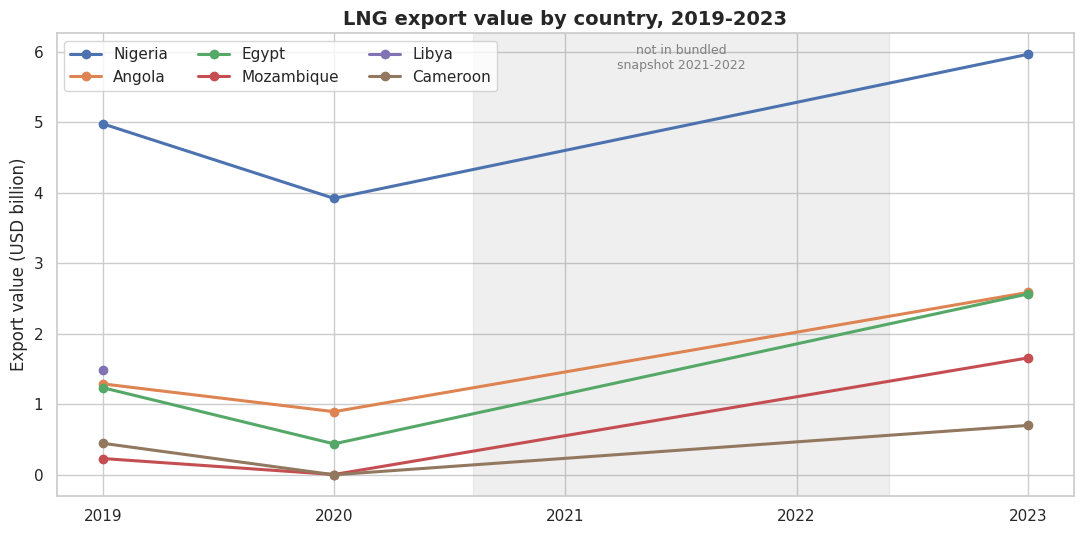

,export_value_billion_usd,usa_export_value_million_usd
year,,
2019,9.68,21.13
2020,5.26,26.74
2023,13.48,262.92


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
major = exports.groupby("country")["export_value_billion_usd"].sum().sort_values(ascending=False)
for country in major.index[:6]:
    d = exports[exports["country"] == country].sort_values("year")
    ax.plot(d["year"], d["export_value_billion_usd"], marker="o", linewidth=2.2, label=country)
ax.set_xticks([2019, 2020, 2021, 2022, 2023])
ax.axvspan(2020.6, 2022.4, color="grey", alpha=0.12)
ax.text(2021.5, ax.get_ylim()[1] * 0.92, "not in bundled\nsnapshot 2021-2022", ha="center", fontsize=9, color="grey")
ax.set_title("LNG export value by country, 2019-2023", fontsize=14, weight="bold")
ax.set_ylabel("Export value (USD billion)")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

totals = exports.groupby("year")[["export_value_billion_usd", "usa_export_value_million_usd"]].sum().round(2)
totals

**Finding.** Combined exports of the reporting countries fell from ≈USD 9.7 bn (2019) to ≈USD 5.3 bn (2020) as the
pandemic crushed spot LNG prices, then rebounded to ≈USD 13.5 bn in 2023 as Europe replaced Russian pipeline gas.
Nigeria's share peaked at ~75% in 2020, when smaller exporters (Cameroon, Mozambique) almost stopped shipping.

## 4. Heatmap — LNG exports by country and year

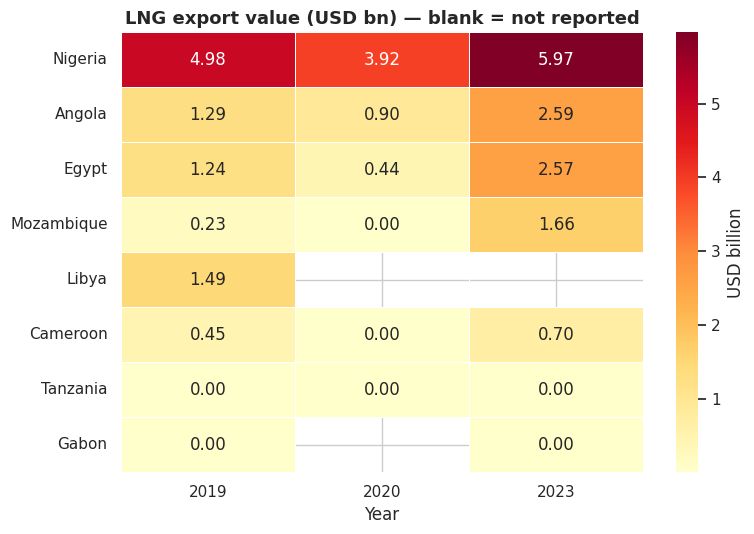

In [7]:
heat = exports.pivot_table(index="country", columns="year", values="export_value_billion_usd", aggfunc="sum")
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 5.5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "USD billion"}, mask=heat.isna())
plt.title("LNG export value (USD bn) — blank = not reported", fontsize=13, weight="bold")
plt.xlabel("Year")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Finding.** Export value is highly concentrated: Nigeria, Angola and Egypt account for ~83% of the 2023 total.
Tanzania and Gabon record only negligible LNG trade (Tanzania's LNG project is still pre-FID), so they are not
material LNG exporters despite holding gas reserves.

## 5. Gas rents (% of GDP) vs GDP per capita

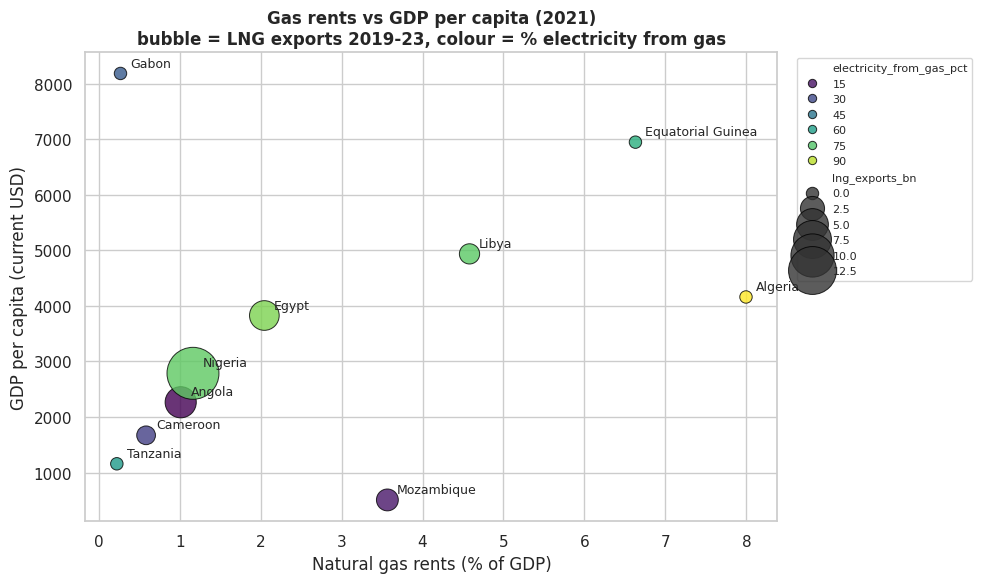

Pearson r (gas rents vs GDP per capita, 2021): 0.292


In [8]:
latest = wb[wb["year"] == 2021].copy()
exp_tot = exports.groupby("country")["export_value_billion_usd"].sum()
latest["lng_exports_bn"] = latest["country"].map(exp_tot).fillna(0)

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=latest, x="gas_rents_pct_gdp", y="gdp_per_capita_usd",
                     size="lng_exports_bn", sizes=(80, 1400), hue="electricity_from_gas_pct",
                     palette="viridis", edgecolor="black", alpha=0.8, legend="brief")
for _, r in latest.iterrows():
    ax.annotate(r["country"], (r["gas_rents_pct_gdp"], r["gdp_per_capita_usd"]),
                xytext=(7, 5), textcoords="offset points", fontsize=9)
ax.set_title("Gas rents vs GDP per capita (2021)\nbubble = LNG exports 2019-23, colour = % electricity from gas",
             fontsize=12, weight="bold")
ax.set_xlabel("Natural gas rents (% of GDP)")
ax.set_ylabel("GDP per capita (current USD)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
print("Pearson r (gas rents vs GDP per capita, 2021):",
      round(latest["gas_rents_pct_gdp"].corr(latest["gdp_per_capita_usd"]), 3))

**Finding.** Gas rents are a larger share of GDP in Algeria (8.0%), Equatorial Guinea (6.6%), Libya (4.6%) and
Mozambique (3.6%). The relationship with income is weak (r ≈ 0.29 in 2021): Mozambique has high gas rents but the lowest GDP per capita
in the group (≈USD 510), while Gabon is the richest in per-capita terms with minimal gas rents (oil drives its economy).
Gas wealth alone does not translate into prosperity — a classic resource-curse signal.

## 6. African LNG exports to the USA

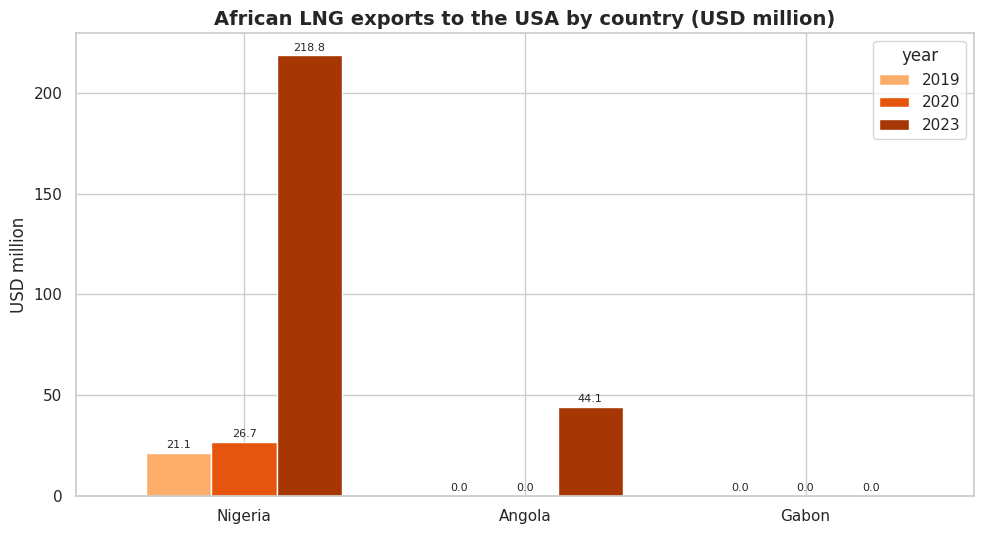

year,2019,2020,2023
reporter,,,
Nigeria,21.128,26.736,218.788
Angola,0.000,0.000,44.129
Gabon,0.005,0.000,0.002


In [9]:
usa = (trade[(trade["flow"] == "X") & (trade["partner_code"] == 842)]
       .assign(usd_m=lambda d: d["trade_value_usd"] / 1e6))
usa_pivot = usa.pivot_table(index="reporter", columns="year", values="usd_m", aggfunc="sum").fillna(0)
usa_pivot = usa_pivot.loc[usa_pivot.sum(axis=1).sort_values(ascending=False).index]

ax = usa_pivot.plot(kind="bar", figsize=(10, 5.5), color=["#fdae6b", "#e6550d", "#a63603"], width=0.7)
ax.set_title("African LNG exports to the USA by country (USD million)", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("USD million")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
usa_pivot.round(3)

In [10]:
share = exports[["country", "year", "usa_export_value_million_usd", "usa_share_pct", "top_destination"]]
share[share["usa_export_value_million_usd"] > 0].round(2)

,country,year,usa_export_value_million_usd,usa_share_pct,top_destination
2,Angola,2023,44.13,1.71,India
9,Gabon,2019,0.00,100.00,USA
10,Gabon,2023,0.00,100.00,USA
15,Nigeria,2019,21.13,0.42,France
16,Nigeria,2020,26.74,0.68,France
17,Nigeria,2023,218.79,3.67,Spain


**Finding.** The USA is a small but fast-growing outlet for African LNG. Nigeria's shipments to the USA rose from
≈USD 21 m (2019) to ≈USD 219 m (2023), and Angola entered the US market in 2023 (≈USD 44 m). Even so, the USA took
only ~3.7% of Nigeria's LNG exports in 2023 — Europe (Spain, France) and Asia (India, China) remain the core
markets. As the world's largest LNG exporter itself, the USA imports cargoes mainly for regional balancing
(e.g. New England terminals), which caps the upside for African suppliers. Gabon's tiny flows all go to the USA.

## 7. Gas dependency score

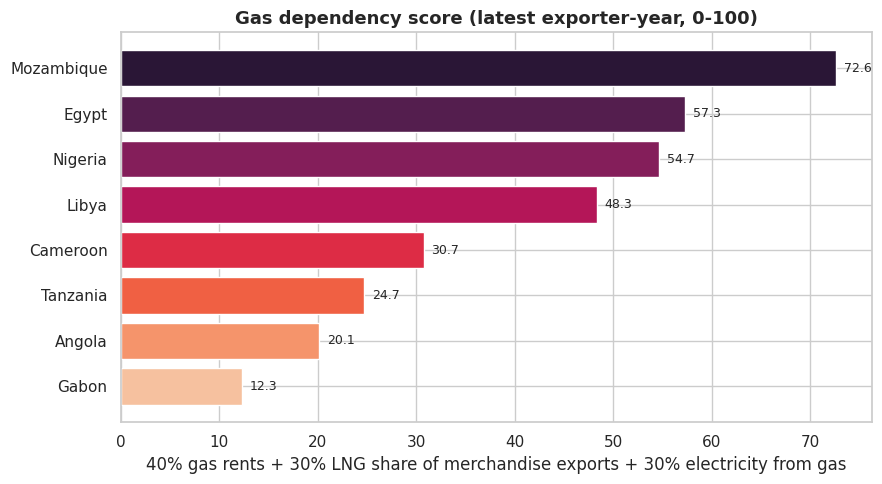

In [11]:
gds = (exports.sort_values("year").groupby("country").tail(1)
       .sort_values("gas_dependency_score", ascending=True))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(gds["country"], gds["gas_dependency_score"], color=sns.color_palette("rocket_r", len(gds)))
ax.set_title("Gas dependency score (latest exporter-year, 0-100)", fontsize=13, weight="bold")
ax.set_xlabel("40% gas rents + 30% LNG share of merchandise exports + 30% electricity from gas")
for i, v in enumerate(gds["gas_dependency_score"]):
    ax.text(v + 0.8, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Finding.** Mozambique scores highest in 2023: LNG reached ~20% of its merchandise exports within a year of
first cargo, and its gas rents are among the highest in the sample. Egypt and Nigeria follow because of very high
gas-fired power shares (≈76–77%), which means domestic demand competes directly with export volumes.

## 8. Summary of findings

| # | Insight |
|---|---------|
| 1 | **Nigeria dominates** African LNG exports (≈USD 14.9 bn across 2019, 2020 and 2023; 44–75% of the reporters' total each year). |
| 2 | **Recovery and growth:** combined exports fell ~46% in 2020 and rebounded to ≈USD 13.5 bn in 2023, driven by Europe's post-2022 demand. |
| 3 | **New entrants:** Mozambique (Coral Sul FLNG) went from negligible to ≈USD 1.7 bn in 2023; Egypt and Angola roughly doubled vs 2019. |
| 4 | **USA flows are small but rising:** ≈USD 21 m (2019) → ≈USD 263 m (2023), led by Nigeria and Angola. The USA is a top destination only for Gabon's token volumes. |
| 5 | **Gas rents ≠ prosperity:** weak correlation (r ≈ 0.29) between gas rents and GDP per capita; Mozambique combines high gas rents with the lowest income. |
| 6 | **Domestic competition:** Algeria (99%), Nigeria (77%) and Egypt (76%) generate most electricity from gas, linking export capacity to domestic power demand. |

**Caveats.** The bundled Comtrade snapshot lacks 2021–2022 and Algeria/Equatorial Guinea; reported quantities (kg) are
inconsistent across reporters, so the analysis relies on USD values. World Bank 2022–2023 rents are carried forward
from 2021 in the processed table.

In [12]:
conn.close()